# BDD curve dataset visualization & sanity checks

**Purpose**: separate from stage1/2/3 experiments. Verify what the joint model is actually being trained on.

Sections:
1. Dataset structure on disk + counts.
2. Random-sample visualizations: image + lane overlay + det boxes.
3. Lane-GT structure (existence, points, visibility) for one sample, raw.
4. Per-image lane-count distribution.
5. Lane-line spatial distribution (heatmap of where lanes appear).
6. Curve length / theta angle histograms.
7. Detection box class/size distribution.

Useful for debugging suspected dataset issues: bad labels, missing classes, label/image mismatch, unbalanced lane positions, etc.

In [1]:
import os, sys, subprocess
from google.colab import drive
drive.mount('/content/drive')
REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyyaml', 'opencv-python-headless', 'matplotlib', 'tqdm'])

# Extract dataset tar if needed (idempotent).
CURVE_TAR = '/content/drive/MyDrive/EcoCAR/datasets/bdd100k_clrkd_curve.tar'
CURVE_ROOT = '/content/bdd100k_clrkd_curve'
import tarfile
if not os.path.exists(CURVE_ROOT) or not os.path.isdir(os.path.join(CURVE_ROOT, 'list')):
    print(f'Extracting {CURVE_TAR}...')
    os.makedirs(CURVE_ROOT, exist_ok=True)
    with tarfile.open(CURVE_TAR, 'r') as tf:
        tf.extractall(CURVE_ROOT)
    print('done')
else:
    print(f'{CURVE_ROOT} already extracted')

print('repo:', REPO_ROOT)
print('dataset root:', CURVE_ROOT)

Mounted at /content/drive
Extracting /content/drive/MyDrive/EcoCAR/datasets/bdd100k_clrkd_curve.tar...


/tmp/ipykernel_2023/3476795049.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(CURVE_ROOT)


done
repo: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane
dataset root: /content/bdd100k_clrkd_curve


## 1. Disk layout + counts

Show the directory tree (top 2 levels only) and count files in each split.

In [2]:
from pathlib import Path
import json

root = Path(CURVE_ROOT)
print('Top-level entries:')
for p in sorted(root.iterdir()):
    if p.is_dir():
        n = sum(1 for _ in p.iterdir())
        print(f'  {p.name}/  ({n} entries)')
    else:
        print(f'  {p.name}  ({p.stat().st_size:,} bytes)')

# Show prepare_summary.json if present.
summary_path = root / 'prepare_summary.json'
if summary_path.exists():
    print('\nprepare_summary.json:')
    print(json.dumps(json.loads(summary_path.read_text()), indent=2))

# Per-split file counts.
print('\nPer-split file counts:')
for split in ('train', 'val'):
    list_file = root / 'list' / ('train_gt.txt' if split == 'train' else 'val.txt')
    if not list_file.exists():
        print(f'  {split}: missing list file {list_file}')
        continue
    n_lines = sum(1 for line in list_file.read_text().splitlines() if line.strip())
    label_dir = root / 'labels' / split
    n_det_labels = len(list(label_dir.glob('*.txt'))) if label_dir.exists() else 0
    n_nonempty_det = sum(1 for p in (label_dir.glob('*.txt') if label_dir.exists() else []) if p.read_text().strip())
    print(f'  {split}: list={n_lines}, det_labels={n_det_labels}, nonempty_det={n_nonempty_det}')

Top-level entries:
  images/  (2 entries)
  labels/  (2 entries)
  list/  (3 entries)
  masks/  (2 entries)
  prepare_summary.json  (935 bytes)

prepare_summary.json:
{
  "output_root": "/content/bdd100k_clrkd_curve",
  "train": {
    "images": 70000,
    "frames_with_lanes": 65813,
    "lane_instances": 414878,
    "lane_json_records": 65813,
    "frames_with_detection": 69389,
    "vehicle_boxes": 755739,
    "detection_label_source": "/content/bdd100k_raw/100k/train",
    "lane_source": "/content/bdd100k_raw/100k/train",
    "image_source": "/content/bdd100k_raw/100k/train"
  },
  "val": {
    "images": 10000,
    "frames_with_lanes": 9425,
    "lane_instances": 59587,
    "lane_json_records": 9425,
    "frames_with_detection": 9905,
    "vehicle_boxes": 108363,
    "detection_label_source": "/content/bdd100k_raw/100k/val",
    "lane_source": "/content/bdd100k_raw/100k/val",
    "image_source": "/content/bdd100k_raw/100k/val"
  },
  "format": "CLRKDNet/CULane-style: image symlinks, 

## 2. Random sample visualizations

Show 6 random training images with overlays:
- Lane curves (read from `*.lines.txt`) drawn as colored polylines.
- Detection boxes (from `labels/<split>/*.txt` in YOLO format) drawn as bounding boxes.

Each row shows a sample at its native resolution; bottom-right shows the GT lane structure (points/visibility).

Total train images: 70000


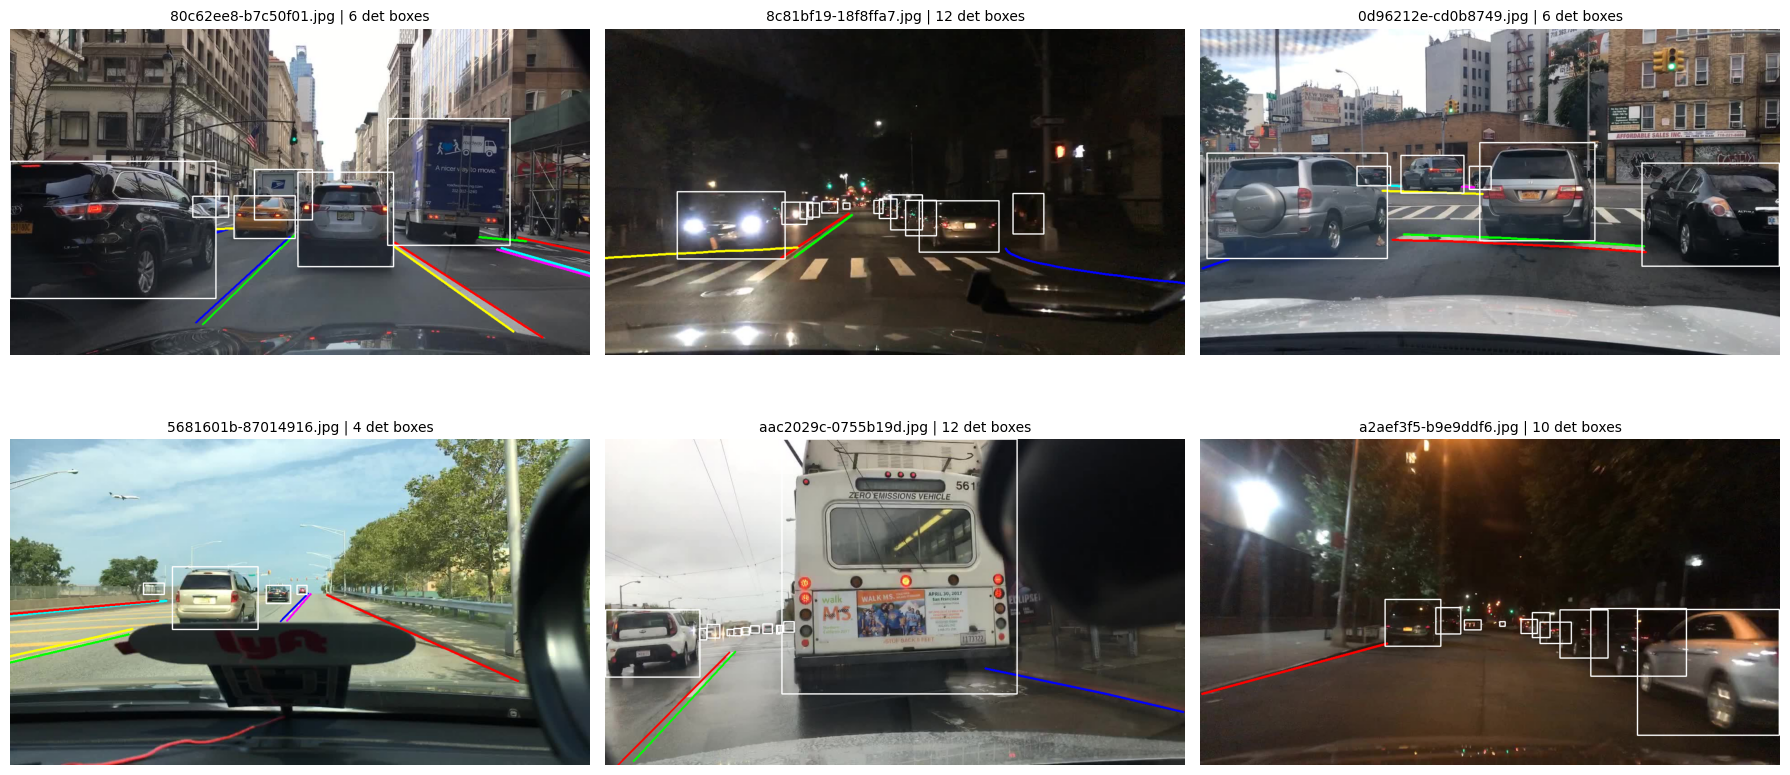

Saved /content/dataset_random_samples.png


In [3]:
import cv2, numpy as np, random
import matplotlib.pyplot as plt
from stage2.scripts.train_joint_model_experiment import read_lines_targets, BDDJointCurveDataset
from stage2.fusion.detection import read_yolo_label

random.seed(0)

# Load list of train images.
list_file = root / 'list' / 'train_gt.txt'
train_items = [root / line.split()[0].lstrip('/') for line in list_file.read_text().splitlines() if line.strip()]
label_dir = root / 'labels' / 'train'
print(f'Total train images: {len(train_items)}')

samples = random.sample(train_items, k=6)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for ax, img_path in zip(axes, samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    # Lane lines.
    line_path = img_path.with_suffix('.lines.txt')
    if line_path.exists():
        text = line_path.read_text().strip()
        for li, line in enumerate(text.splitlines()):
            coords = [float(x) for x in line.split()]
            xs, ys = coords[0::2], coords[1::2]
            valid = [(x, y) for x, y in zip(xs, ys) if x >= 0 and y >= 0]
            if len(valid) >= 2:
                pts = np.array(valid, dtype=np.int32).reshape(-1, 1, 2)
                color = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255),(0,255,255)][li % 6]
                cv2.polylines(img, [pts], False, color, thickness=4)
    # Det boxes (YOLO format: cls cx cy w h, normalized).
    det_label = label_dir / f'{img_path.stem}.txt'
    n_boxes = 0
    if det_label.exists():
        for box_line in det_label.read_text().splitlines():
            parts = box_line.split()
            if len(parts) < 5:
                continue
            cls, cx, cy, bw, bh = map(float, parts[:5])
            x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), 2)
            n_boxes += 1
    ax.imshow(img)
    ax.set_title(f'{img_path.name} | {n_boxes} det boxes', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/dataset_random_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved /content/dataset_random_samples.png')

## 3. Raw lane-GT tensor for one sample

Inspect the actual tensors fed to the model: existence (binary mask of which lane slots have GTs), points (x,y per row in normalized coords), visibility (0/1 per row whether the lane has a point at that row).

This shows how `read_lines_targets` turns raw `*.lines.txt` into the fixed-size 12x72x2 tensor.

In [4]:
import numpy as np

# Pick a non-trivial sample (one with multiple lanes).
sample_path = None
for cand in train_items:
    line_path = cand.with_suffix('.lines.txt')
    if line_path.exists() and len(line_path.read_text().strip().splitlines()) >= 3:
        sample_path = cand
        break

print(f'Sample image: {sample_path}')
img = cv2.imread(str(sample_path))
h, w = img.shape[:2]
print(f'Image size: {w}x{h}')

lane = read_lines_targets(sample_path.with_suffix('.lines.txt'), max_lanes=12, num_points=72, img_w=w, img_h=h)
print(f"existence: shape={lane['existence'].shape} dtype={lane['existence'].dtype}")
print(f'  values: {lane["existence"].tolist()}')
print(f"points: shape={lane['points'].shape} dtype={lane['points'].dtype}")
print(f"visibility: shape={lane['visibility'].shape} dtype={lane['visibility'].dtype}")
vis_per_lane = lane['visibility'].sum(axis=-1)
print(f'  visible-rows-per-lane (max=72): {vis_per_lane.tolist()}')

# Show the first 3 lane points.
for li in range(min(3, int(lane['existence'].sum()))):
    pts = lane['points'][li]
    vis = lane['visibility'][li]
    n_vis = int(vis.sum())
    print(f'\nLane {li}: {n_vis} visible rows')
    print(f'  first 5 visible points (x_norm, y_norm):')
    cnt = 0
    for i, v in enumerate(vis):
        if v > 0.5 and cnt < 5:
            print(f'    row {i}: x={pts[i,0]:.3f}, y={pts[i,1]:.3f}')
            cnt += 1

Sample image: /content/bdd100k_clrkd_curve/images/train/0000f77c-6257be58.jpg
Image size: 1280x720
existence: shape=(12,) dtype=float32
  values: [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
points: shape=(12, 72, 2) dtype=float32
visibility: shape=(12, 72) dtype=float32
  visible-rows-per-lane (max=72): [72.0, 72.0, 72.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Lane 0: 72 visible rows
  first 5 visible points (x_norm, y_norm):
    row 0: x=0.996, y=0.523
    row 1: x=0.992, y=0.522
    row 2: x=0.988, y=0.522
    row 3: x=0.984, y=0.522
    row 4: x=0.979, y=0.522

Lane 1: 72 visible rows
  first 5 visible points (x_norm, y_norm):
    row 0: x=0.049, y=0.516
    row 1: x=0.049, y=0.516
    row 2: x=0.048, y=0.516
    row 3: x=0.047, y=0.516
    row 4: x=0.046, y=0.516

Lane 2: 72 visible rows
  first 5 visible points (x_norm, y_norm):
    row 0: x=0.393, y=0.518
    row 1: x=0.392, y=0.518
    row 2: x=0.390, y=0.518
    row 3: x=0.389, y=0.518
    row 4: x=0.387

## 4. Lane count distribution per image

How many GT lane lines does each image have? Crucial because:
- LaneQueryHead uses K=12 queries; if most images have <5 lanes, we have lots of unused queries.
- CLRKDLaneHead uses 192 anchors with dynamic-k matching; the imbalance ratio determines cls difficulty.

counting lanes: 100%|██████████| 3000/3000 [00:00<00:00, 32275.05it/s]


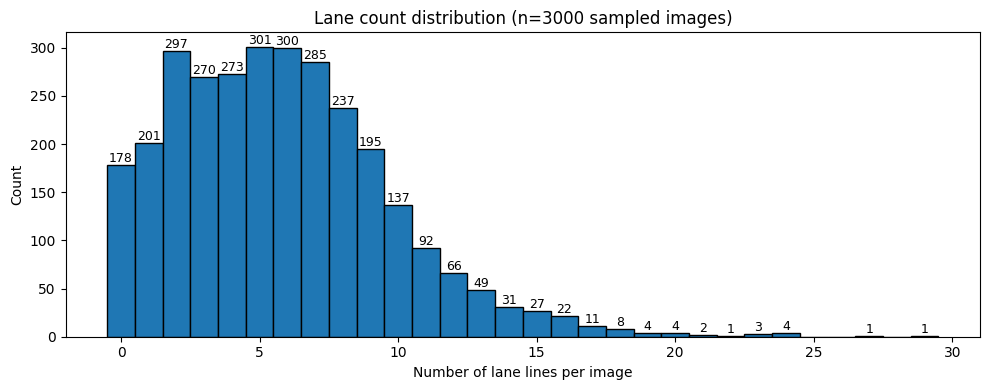

Mean: 5.81 | Median: 5.0 | Max: 29
Images with 0 lanes: 178 (5.9%)
Images with >=12 lanes (saturated): 234 (7.8%)


In [5]:
from tqdm import tqdm
import matplotlib.pyplot as plt

# Sample ~3000 images for speed; if dataset is small, use all.
sample_size = min(3000, len(train_items))
sampled = random.sample(train_items, k=sample_size)

lane_counts = []
lane_lengths = []  # length in normalized image units
for img_path in tqdm(sampled, desc='counting lanes'):
    line_path = img_path.with_suffix('.lines.txt')
    if not line_path.exists():
        lane_counts.append(0)
        continue
    text = line_path.read_text().strip()
    n = 0
    for line in text.splitlines():
        coords = [float(x) for x in line.split()]
        xs, ys = coords[0::2], coords[1::2]
        valid = [(x, y) for x, y in zip(xs, ys) if x >= 0 and y >= 0]
        if len(valid) >= 2:
            n += 1
    lane_counts.append(n)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lane_counts, bins=range(0, max(lane_counts)+2), edgecolor='black', align='left')
ax.set_xlabel('Number of lane lines per image')
ax.set_ylabel('Count')
ax.set_title(f'Lane count distribution (n={sample_size} sampled images)')
for n, freq in sorted(dict(zip(*np.unique(lane_counts, return_counts=True))).items()):
    ax.text(n, freq, f'{freq}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/dataset_lane_count_dist.png', dpi=100)
plt.show()
import statistics
print(f'Mean: {statistics.mean(lane_counts):.2f} | Median: {statistics.median(lane_counts)} | Max: {max(lane_counts)}')
print(f'Images with 0 lanes: {sum(1 for c in lane_counts if c == 0)} ({sum(1 for c in lane_counts if c == 0) / sample_size * 100:.1f}%)')
print(f'Images with >=12 lanes (saturated): {sum(1 for c in lane_counts if c >= 12)} ({sum(1 for c in lane_counts if c >= 12) / sample_size * 100:.1f}%)')

## 5. Lane spatial distribution heatmap

Where do lanes appear in the image? This guides anchor/query placement: if lanes cluster in the bottom half, queries should be initialized near bottom rows.

building heatmap: 100%|██████████| 3000/3000 [00:00<00:00, 25176.60it/s]


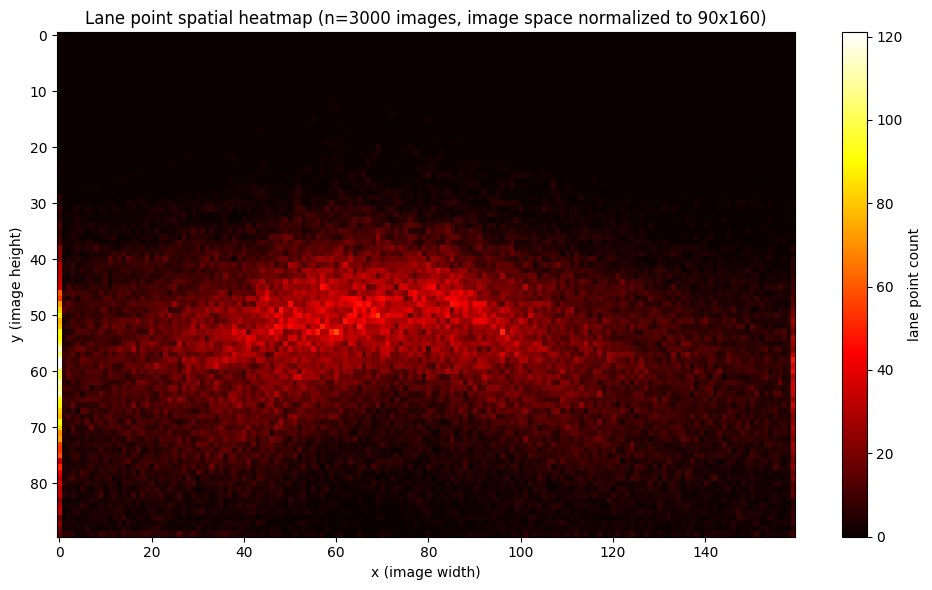

In [6]:
heatmap = np.zeros((90, 160), dtype=np.float32)
for img_path in tqdm(sampled, desc='building heatmap'):
    line_path = img_path.with_suffix('.lines.txt')
    if not line_path.exists():
        continue
    text = line_path.read_text().strip()
    img_h, img_w = 720, 1280
    for line in text.splitlines():
        coords = [float(x) for x in line.split()]
        xs, ys = coords[0::2], coords[1::2]
        for x, y in zip(xs, ys):
            if x < 0 or y < 0 or x >= img_w or y >= img_h:
                continue
            hi = int(y / img_h * 90)
            wi = int(x / img_w * 160)
            if 0 <= hi < 90 and 0 <= wi < 160:
                heatmap[hi, wi] += 1

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap, cmap='hot', interpolation='nearest', aspect='auto')
ax.set_title(f'Lane point spatial heatmap (n={sample_size} images, image space normalized to 90x160)')
ax.set_xlabel('x (image width)')
ax.set_ylabel('y (image height)')
plt.colorbar(im, label='lane point count')
plt.tight_layout()
plt.savefig('/content/dataset_lane_spatial_heatmap.png', dpi=100)
plt.show()

## 6. Lane geometry stats: theta + length

What angles do lanes occupy? CLRKDLaneHead's anchor priors initialize at specific (theta, start) values; if the dataset's lane angle distribution differs from those, the priors are mismatched and cls struggles.

computing geom: 100%|██████████| 500/500 [00:00<00:00, 31599.80it/s]


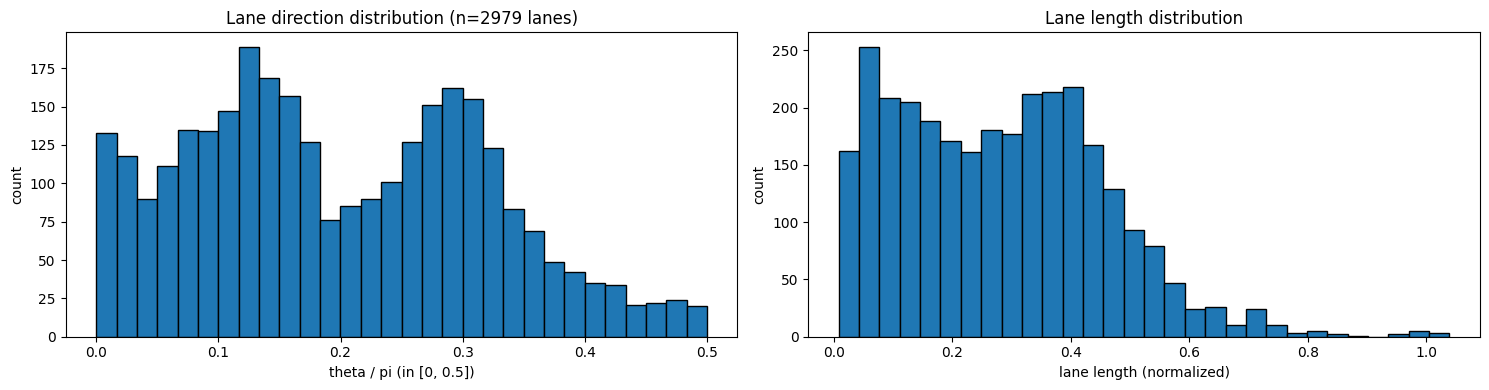

theta: mean=0.198, median=0.181, std=0.119
length: mean=0.281, median=0.276, std=0.174


In [7]:
import math
thetas = []
lengths_norm = []
for img_path in tqdm(sampled[:500], desc='computing geom'):
    line_path = img_path.with_suffix('.lines.txt')
    if not line_path.exists():
        continue
    text = line_path.read_text().strip()
    img_h, img_w = 720, 1280
    for line in text.splitlines():
        coords = [float(x) for x in line.split()]
        xs, ys = coords[0::2], coords[1::2]
        valid = [(x, y) for x, y in zip(xs, ys) if x >= 0 and y >= 0]
        if len(valid) < 2:
            continue
        x0, y0 = valid[0]
        x1, y1 = valid[-1]
        dx = (x1 - x0) / img_w
        dy = (y1 - y0) / img_h
        theta = math.atan2(abs(dy) + 1e-4, abs(dx) + 1e-4) / math.pi  # in [0, 0.5]
        length = math.sqrt(dx*dx + dy*dy)
        thetas.append(theta)
        lengths_norm.append(length)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(thetas, bins=30, edgecolor='black')
axes[0].set_xlabel('theta / pi (in [0, 0.5])')
axes[0].set_ylabel('count')
axes[0].set_title(f'Lane direction distribution (n={len(thetas)} lanes)')
axes[1].hist(lengths_norm, bins=30, edgecolor='black')
axes[1].set_xlabel('lane length (normalized)')
axes[1].set_ylabel('count')
axes[1].set_title('Lane length distribution')
plt.tight_layout()
plt.savefig('/content/dataset_lane_geom_stats.png', dpi=100)
plt.show()
import statistics
print(f'theta: mean={statistics.mean(thetas):.3f}, median={statistics.median(thetas):.3f}, std={statistics.stdev(thetas):.3f}')
print(f'length: mean={statistics.mean(lengths_norm):.3f}, median={statistics.median(lengths_norm):.3f}, std={statistics.stdev(lengths_norm):.3f}')

## 7. Detection: box class + size distribution

What is the joint detection task actually trying to detect? If most boxes are tiny / one class dominates, that explains why mAP50 has been ~0.005.

counting boxes: 100%|██████████| 3000/3000 [00:00<00:00, 38696.53it/s]


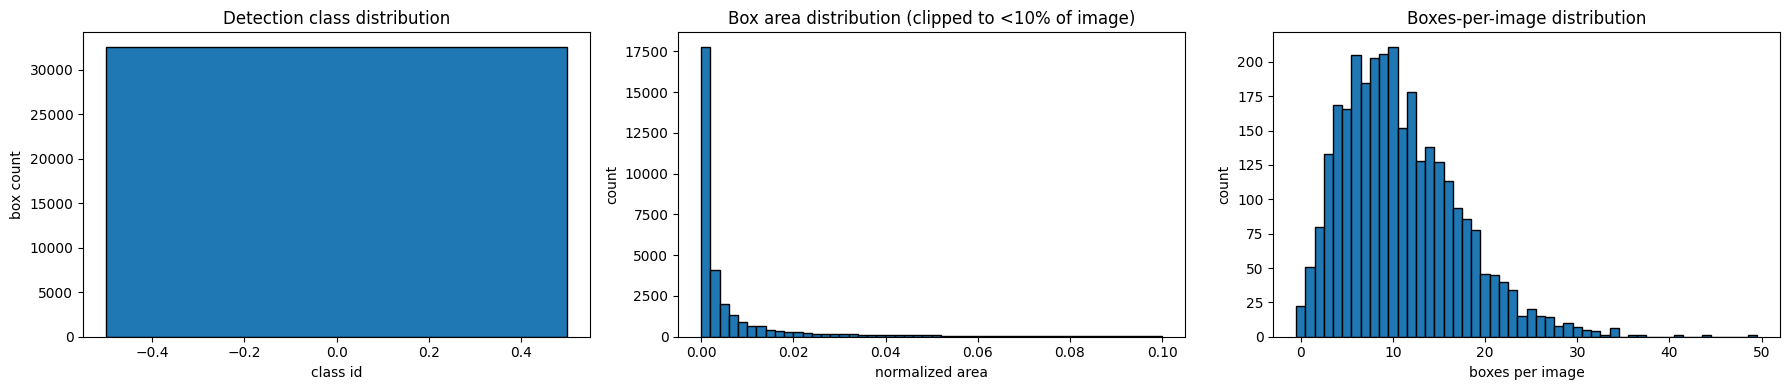

Class counts: {0: 32580}
Mean boxes per image: 10.86
Tiny boxes (<0.1% of image): 13073/32580 (40.1%)


In [8]:
box_classes = []
box_areas = []  # normalized area (w*h)
boxes_per_image = []
for img_path in tqdm(sampled, desc='counting boxes'):
    label = label_dir / f'{img_path.stem}.txt'
    if not label.exists():
        boxes_per_image.append(0)
        continue
    n = 0
    for line in label.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls, cx, cy, bw, bh = map(float, parts[:5])
        box_classes.append(int(cls))
        box_areas.append(bw * bh)
        n += 1
    boxes_per_image.append(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(box_classes, bins=range(0, max(box_classes)+2), edgecolor='black', align='left')
axes[0].set_xlabel('class id')
axes[0].set_ylabel('box count')
axes[0].set_title('Detection class distribution')
axes[1].hist([a for a in box_areas if a < 0.1], bins=50, edgecolor='black')
axes[1].set_xlabel('normalized area')
axes[1].set_ylabel('count')
axes[1].set_title('Box area distribution (clipped to <10% of image)')
axes[2].hist(boxes_per_image, bins=range(0, max(boxes_per_image)+2), edgecolor='black', align='left')
axes[2].set_xlabel('boxes per image')
axes[2].set_ylabel('count')
axes[2].set_title('Boxes-per-image distribution')
plt.tight_layout()
plt.savefig('/content/dataset_det_stats.png', dpi=100)
plt.show()
from collections import Counter
print('Class counts:', dict(Counter(box_classes).most_common()))
print(f'Mean boxes per image: {sum(boxes_per_image)/len(boxes_per_image):.2f}')
tiny = sum(1 for a in box_areas if a < 0.001)
print(f'Tiny boxes (<0.1% of image): {tiny}/{len(box_areas)} ({tiny/max(1,len(box_areas))*100:.1f}%)')

## 8. Sanity checks summary

Print a one-screen summary of dataset health: are there enough non-empty samples, is the lane count distribution sane, do det boxes have reasonable sizes.

In [9]:
print('=' * 60)
print('DATASET HEALTH SUMMARY')
print('=' * 60)
print(f'Train samples: {len(train_items)}')
for split in ('train', 'val'):
    list_file = root / 'list' / ('train_gt.txt' if split == 'train' else 'val.txt')
    if list_file.exists():
        n = sum(1 for line in list_file.read_text().splitlines() if line.strip())
        print(f'  {split}: {n}')
print()
print(f'Lane stats (sampled n={sample_size}):')
print(f'  mean lanes/image: {sum(lane_counts)/len(lane_counts):.2f}')
print(f'  zero-lane images: {sum(1 for c in lane_counts if c == 0)} ({sum(1 for c in lane_counts if c == 0)/len(lane_counts)*100:.1f}%)')
print(f'  saturated (>=12 lanes): {sum(1 for c in lane_counts if c >= 12)}')
print(f'  mean theta/pi: {statistics.mean(thetas):.3f}')
print(f'  mean lane length (normalized): {statistics.mean(lengths_norm):.3f}')
print()
print(f'Det stats (sampled n={sample_size}):')
print(f'  total boxes: {len(box_classes)}')
print(f'  mean boxes/image: {sum(boxes_per_image)/len(boxes_per_image):.2f}')
print(f'  unique classes: {sorted(set(box_classes))}')
print(f'  tiny boxes (<0.1% area): {tiny/max(1,len(box_areas))*100:.1f}%')
print()
print('Possible issues to investigate if metrics are stuck:')
print('  - If lane mean is < 3, the dataset is sparse (many no-lane images dilute signal).')
print('  - If theta distribution is heavily concentrated, anchor priors at uniform theta are mismatched.')
print('  - If detection has only 1 class and >50% tiny boxes, mAP50 = 0.005 is normal.')
print('  - If saturated lane count is high (>5%), max_lanes=12 is truncating real GT.')

DATASET HEALTH SUMMARY
Train samples: 70000
  train: 70000
  val: 10000

Lane stats (sampled n=3000):
  mean lanes/image: 5.81
  zero-lane images: 178 (5.9%)
  saturated (>=12 lanes): 234
  mean theta/pi: 0.198
  mean lane length (normalized): 0.281

Det stats (sampled n=3000):
  total boxes: 32580
  mean boxes/image: 10.86
  unique classes: [0]
  tiny boxes (<0.1% area): 40.1%

Possible issues to investigate if metrics are stuck:
  - If lane mean is < 3, the dataset is sparse (many no-lane images dilute signal).
  - If theta distribution is heavily concentrated, anchor priors at uniform theta are mismatched.
  - If detection has only 1 class and >50% tiny boxes, mAP50 = 0.005 is normal.
  - If saturated lane count is high (>5%), max_lanes=12 is truncating real GT.
